Cell 1 - Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

Cell 2 - Select CPU or GPU

In [2]:
device = torch.device(
"cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device:", device)

Using device: cpu


Cell 3 - Main parameters

In [3]:
# ============================================================
# CELL 3 - MAIN PARAMETERS
# ============================================================

SEED = 42

# Dataset
N_DATA = 10000
MOON_NOISE = 0.08

# DDPM experiment
T_VALUES = [100, 1000]

# Training
N_TRAIN_PAIRS = 60000
BATCH_SIZE = 512
EPOCHS = 70
LEARNING_RATE = 0.001

# Noise schedule
BETA_START = 0.0001
BETA_END = 0.02

# Generation
N_GENERATED_VALUES = [1000, 5000]

print("T values:", T_VALUES)
print("Generated sample sizes:", N_GENERATED_VALUES)

T values: [100, 1000]
Generated sample sizes: [1000, 5000]


Cell 4 - Fix random seed

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
 torch.cuda.manual_seed_all(SEED)

**PART C - Create the Two Moons dataset**

Cell 5 - Generate Two Moons

In [5]:
X, y = make_moons(
n_samples=N_DATA,
noise=MOON_NOISE,
random_state=SEED
)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 2)
y shape: (10000,)


Cell 6 - Plot the dataset

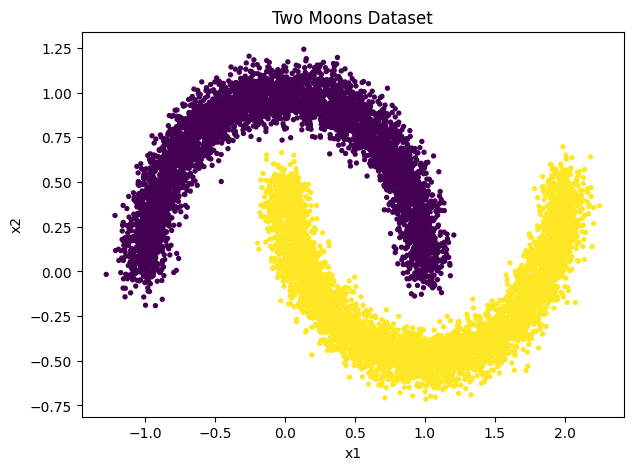

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(
X[:, 0],
X[:, 1],
c=y,
s=8
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two Moons Dataset")
plt.show()

**PART D - Train/test split**

Cell 7 - Split the data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=SEED,
stratify=y
)
print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Training data: (8000, 2)
Test data: (2000, 2)


# **PART E - Standardization without test leakage**

Cell 8 - Scale correctly

In [8]:
scaler = StandardScaler()
# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(
X_train
)
# Apply the same scaler to test data
X_test_scaled = scaler.transform(
X_test
)
print(X_train_scaled.shape)

(8000, 2)


# **Update the code(19-31)**

DIFFUSION SCHEDULE CHECK

T = 100
Beta start: 9.999999747378752e-05
Beta end: 0.18899574875831604
Final alpha_bar: 4.035828897031024e-05
Remaining signal: 0.006352817174047232

T = 1000
Beta start: 9.999999747378752e-05
Beta end: 0.019999999552965164
Final alpha_bar: 4.035830352222547e-05
Remaining signal: 0.006352818571031094


TRAINING DDPM: T = 100
Training input: torch.Size([60000, 3])
Training target: torch.Size([60000, 2])
T=100 | Epoch 1/70 | Loss = 0.352740
T=100 | Epoch 10/70 | Loss = 0.247852
T=100 | Epoch 20/70 | Loss = 0.243780
T=100 | Epoch 30/70 | Loss = 0.241389
T=100 | Epoch 40/70 | Loss = 0.240201
T=100 | Epoch 50/70 | Loss = 0.239535
T=100 | Epoch 60/70 | Loss = 0.238845
T=100 | Epoch 70/70 | Loss = 0.237837

Final loss for T=100: 0.237837


TRAINING DDPM: T = 1000
Training input: torch.Size([60000, 3])
Training target: torch.Size([60000, 2])
T=1000 | Epoch 1/70 | Loss = 0.345155
T=1000 | Epoch 10/70 | Loss = 0.239717
T=1000 | Epoch 20/70 | Loss = 0.235498
T=1000 | Ep

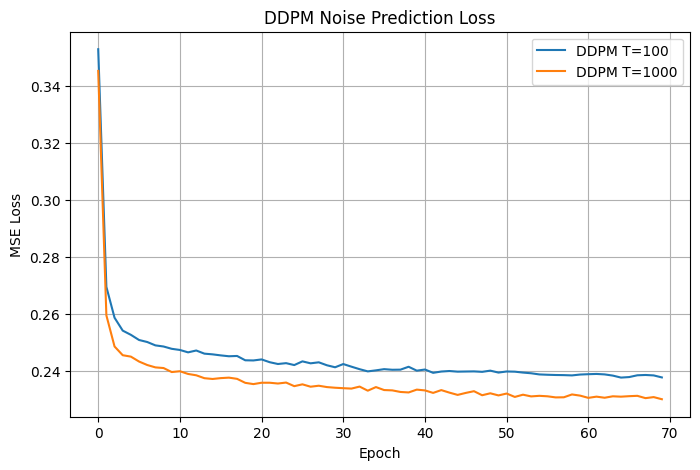



GENERATING DDPM T=100, N=1000
Sampling time: 0.1641845703125 seconds


GENERATING DDPM T=100, N=5000
Sampling time: 1.480201005935669 seconds


GENERATING DDPM T=1000, N=1000
Sampling time: 2.1765949726104736 seconds


GENERATING DDPM T=1000, N=5000
Sampling time: 11.086198329925537 seconds


DDPM SAMPLING TIME
T100_N1000 -> 0.1642 seconds
T100_N5000 -> 1.4802 seconds
T1000_N1000 -> 2.1766 seconds
T1000_N5000 -> 11.0862 seconds
K=2 | BIC=41125.61
K=4 | BIC=33011.47
K=8 | BIC=27170.71
K=16 | BIC=26605.53

Selected GMM K = 16


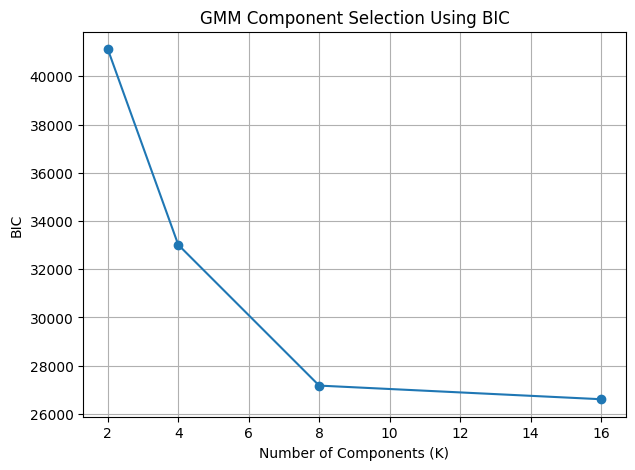

GMM N=1000 | Time=0.019490 seconds
GMM N=5000 | Time=0.002726 seconds


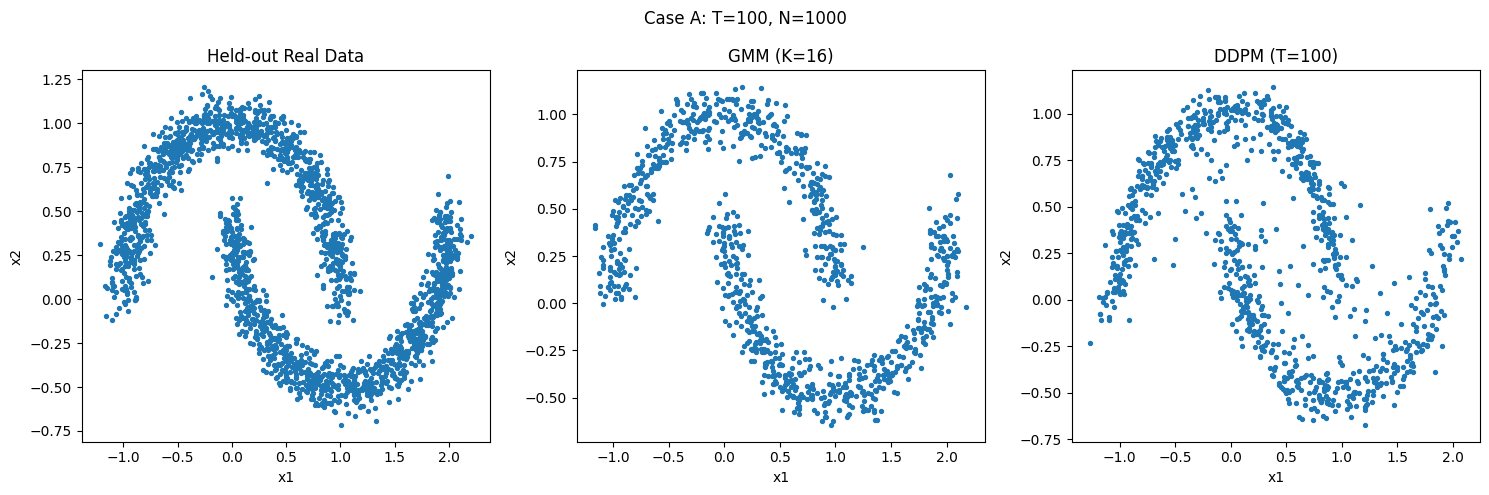

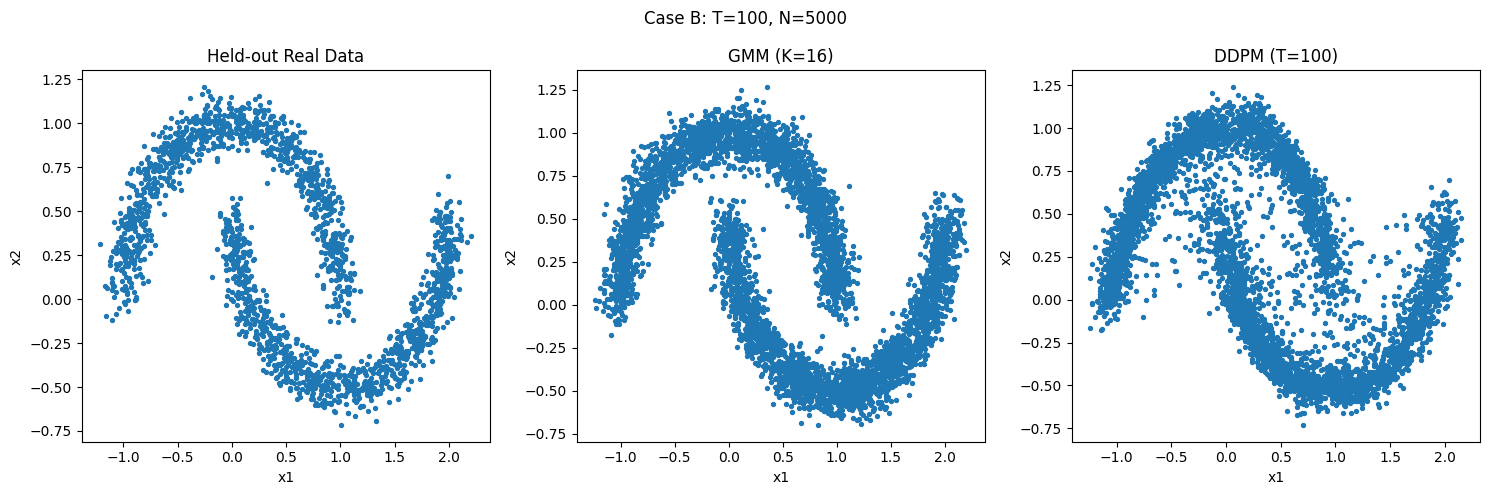

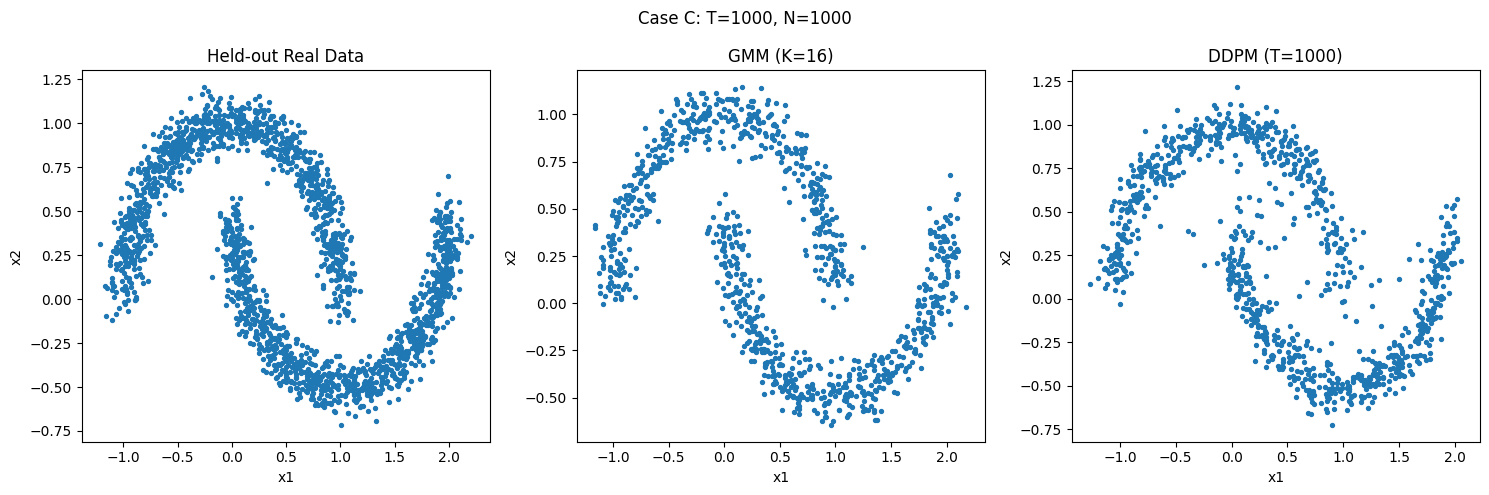

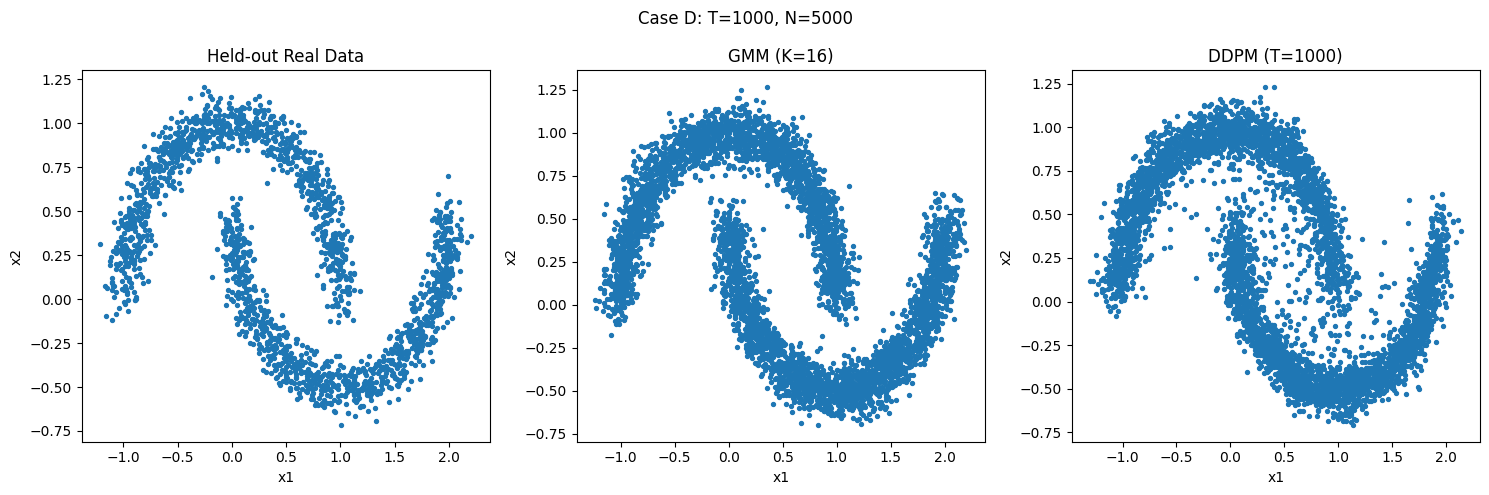



FINAL SAMPLING TIME TABLE
Case Model    T  N_generated  Sampling_time_sec
   -   GMM    -         1000           0.019490
   -   GMM    -         5000           0.002726
   A  DDPM  100         1000           0.164185
   B  DDPM  100         5000           1.480201
   C  DDPM 1000         1000           2.176595
   D  DDPM 1000         5000          11.086198


In [9]:
# ============================================================
# DDPM T=100 vs T=1000 EXPERIMENT
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 1. CREATE COMPARABLE DIFFUSION SCHEDULE
# ============================================================

def create_beta_schedule(T):

    # Reference schedule for T=1000
    beta_1000 = torch.linspace(
        BETA_START,
        BETA_END,
        1000,
        device=device
    )

    alpha_1000 = 1.0 - beta_1000

    alpha_bar_1000 = torch.cumprod(
        alpha_1000,
        dim=0
    )

    target_final_alpha_bar = (
        alpha_bar_1000[-1]
    )

    # --------------------------------------------------------
    # T = 1000 uses the original linear schedule
    # --------------------------------------------------------

    if T == 1000:

        beta = beta_1000

    # --------------------------------------------------------
    # T = 100 uses a schedule adjusted so that the
    # final noise level is comparable to T = 1000
    # --------------------------------------------------------

    elif T == 100:

        low = BETA_START
        high = 0.5

        for _ in range(60):

            candidate_end = (
                low + high
            ) / 2.0

            beta_candidate = torch.linspace(
                BETA_START,
                candidate_end,
                T,
                device=device
            )

            alpha_candidate = (
                1.0 - beta_candidate
            )

            alpha_bar_candidate = torch.cumprod(
                alpha_candidate,
                dim=0
            )[-1]

            if (
                alpha_bar_candidate
                >
                target_final_alpha_bar
            ):
                low = candidate_end
            else:
                high = candidate_end

        beta = torch.linspace(
            BETA_START,
            high,
            T,
            device=device
        )

    else:

        raise ValueError(
            "T must be 100 or 1000."
        )

    return beta


# ============================================================
# 2. CHECK BOTH DIFFUSION SCHEDULES
# ============================================================

print("=" * 60)
print("DIFFUSION SCHEDULE CHECK")
print("=" * 60)

for T in T_VALUES:

    beta_test = create_beta_schedule(T)

    alpha_test = (
        1.0 - beta_test
    )

    alpha_bar_test = torch.cumprod(
        alpha_test,
        dim=0
    )

    print("\nT =", T)

    print(
        "Beta start:",
        beta_test[0].item()
    )

    print(
        "Beta end:",
        beta_test[-1].item()
    )

    print(
        "Final alpha_bar:",
        alpha_bar_test[-1].item()
    )

    print(
        "Remaining signal:",
        torch.sqrt(
            alpha_bar_test[-1]
        ).item()
    )


# ============================================================
# 3. DDPM NETWORK
# ============================================================

class NoisePredictor(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(3, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, 2)
        )

    def forward(self, x):

        return self.model(x)


# ============================================================
# 4. CREATE TRAINING DATA FOR ONE T
# ============================================================

def create_training_data(T, beta):

    alpha = (
        1.0 - beta
    )

    alpha_bar = torch.cumprod(
        alpha,
        dim=0
    )

    # Reproducible random generator
    rng = np.random.default_rng(
        SEED + T
    )

    # Select random clean training observations
    indices = rng.integers(
        0,
        len(X_train_scaled),
        N_TRAIN_PAIRS
    )

    x0 = X_train_scaled[
        indices
    ]

    # Select random diffusion timestep
    t = rng.integers(
        0,
        T,
        N_TRAIN_PAIRS
    )

    # Gaussian noise
    epsilon = rng.normal(
        size=x0.shape
    )

    # Convert to tensors
    x0_tensor = torch.tensor(
        x0,
        dtype=torch.float32
    )

    t_tensor = torch.tensor(
        t,
        dtype=torch.long
    )

    epsilon_tensor = torch.tensor(
        epsilon,
        dtype=torch.float32
    )

    # Select alpha_bar for every sample
    a_bar = (
        alpha_bar
        .detach()
        .cpu()
        [t_tensor]
        .unsqueeze(1)
    )

    # Forward diffusion
    xt = (
        torch.sqrt(a_bar)
        * x0_tensor
        +
        torch.sqrt(
            1.0 - a_bar
        )
        * epsilon_tensor
    )

    # Normalize timestep
    t_scaled = (
        t_tensor.float()
        /
        (T - 1)
    ).unsqueeze(1)

    # Network input:
    # x1, x2, timestep
    network_input = torch.cat(
        [
            xt,
            t_scaled
        ],
        dim=1
    )

    # Target = Gaussian noise
    network_target = epsilon_tensor

    return (
        network_input,
        network_target,
        alpha,
        alpha_bar
    )


# ============================================================
# 5. TRAIN ONE DDPM MODEL
# ============================================================

def train_ddpm(T):

    print("\n")
    print("=" * 60)
    print(f"TRAINING DDPM: T = {T}")
    print("=" * 60)

    # Reproducibility
    seed_here = SEED + T

    random.seed(
        seed_here
    )

    np.random.seed(
        seed_here
    )

    torch.manual_seed(
        seed_here
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed_here
        )

    # Create schedule
    beta = create_beta_schedule(T)

    # Create training data
    (
        network_input,
        network_target,
        alpha,
        alpha_bar
    ) = create_training_data(
        T,
        beta
    )

    print(
        "Training input:",
        network_input.shape
    )

    print(
        "Training target:",
        network_target.shape
    )

    # Dataset
    dataset = TensorDataset(
        network_input,
        network_target
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    # Model
    model = NoisePredictor().to(
        device
    )

    # Loss
    loss_function = nn.MSELoss()

    # Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    # Training history
    loss_history = []

    # Training loop
    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0.0

        for batch_x, batch_y in loader:

            batch_x = batch_x.to(
                device
            )

            batch_y = batch_y.to(
                device
            )

            optimizer.zero_grad()

            prediction = model(
                batch_x
            )

            loss = loss_function(
                prediction,
                batch_y
            )

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
            )

        average_loss = (
            total_loss
            /
            len(loader)
        )

        loss_history.append(
            average_loss
        )

        # Print every 10 epochs
        if (
            epoch == 0
            or
            (epoch + 1) % 10 == 0
            or
            epoch == EPOCHS - 1
        ):

            print(
                f"T={T} | "
                f"Epoch "
                f"{epoch + 1}/{EPOCHS} | "
                f"Loss = "
                f"{average_loss:.6f}"
            )

    print(
        f"\nFinal loss for T={T}: "
        f"{loss_history[-1]:.6f}"
    )

    return {
        "T": T,
        "model": model,
        "beta": beta,
        "alpha": alpha,
        "alpha_bar": alpha_bar,
        "loss_history": loss_history
    }


# ============================================================
# 6. TRAIN T=100
# ============================================================

ddpm_100 = train_ddpm(
    T=100
)


# ============================================================
# 7. TRAIN T=1000
# ============================================================

ddpm_1000 = train_ddpm(
    T=1000
)


# ============================================================
# 8. PLOT TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    ddpm_100["loss_history"],
    label="DDPM T=100"
)

plt.plot(
    ddpm_1000["loss_history"],
    label="DDPM T=1000"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "DDPM Noise Prediction Loss"
)

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 9. DDPM REVERSE SAMPLING
# ============================================================

@torch.no_grad()
def generate_ddpm(
    ddpm_result,
    n_samples
):

    model = ddpm_result[
        "model"
    ]

    beta = ddpm_result[
        "beta"
    ]

    alpha = ddpm_result[
        "alpha"
    ]

    alpha_bar = ddpm_result[
        "alpha_bar"
    ]

    T = ddpm_result[
        "T"
    ]

    model.eval()

    # Previous alpha_bar
    alpha_bar_prev = torch.cat(
        [
            torch.ones(
                1,
                device=device
            ),
            alpha_bar[:-1]
        ]
    )

    # Start from Gaussian noise
    x = torch.randn(
        n_samples,
        2,
        device=device
    )

    # Reverse diffusion
    for step in reversed(
        range(T)
    ):

        # Normalize timestep
        t_value = (
            step
            /
            (T - 1)
        )

        t_column = torch.full(
            (
                n_samples,
                1
            ),
            t_value,
            device=device
        )

        # Model input
        model_input = torch.cat(
            [
                x,
                t_column
            ],
            dim=1
        )

        # Predict noise
        predicted_noise = model(
            model_input
        )

        beta_t = beta[
            step
        ]

        alpha_t = alpha[
            step
        ]

        alpha_bar_t = alpha_bar[
            step
        ]

        # Reverse mean
        mean = (
            1.0
            /
            torch.sqrt(
                alpha_t
            )
        ) * (
            x
            -
            (
                beta_t
                /
                torch.sqrt(
                    1.0
                    -
                    alpha_bar_t
                )
            )
            * predicted_noise
        )

        # Add stochastic noise
        if step > 0:

            posterior_variance = (
                beta_t
                *
                (
                    1.0
                    -
                    alpha_bar_prev[
                        step
                    ]
                )
                /
                (
                    1.0
                    -
                    alpha_bar_t
                )
            )

            noise = torch.randn_like(
                x
            )

            x = (
                mean
                +
                torch.sqrt(
                    posterior_variance
                )
                * noise
            )

        else:

            x = mean

    return x.cpu().numpy()


# ============================================================
# 10. GENERATE ALL FOUR DDPM CASES
# ============================================================

ddpm_results = {}

for T in [
    100,
    1000
]:

    if T == 100:

        model_result = ddpm_100

    else:

        model_result = ddpm_1000

    for n_generated in [
        1000,
        5000
    ]:

        print("\n")
        print("=" * 60)

        print(
            f"GENERATING DDPM "
            f"T={T}, "
            f"N={n_generated}"
        )

        start_time = time.time()

        X_generated_scaled = (
            generate_ddpm(
                model_result,
                n_generated
            )
        )

        sampling_time = (
            time.time()
            -
            start_time
        )

        # Convert back to original scale
        X_generated = (
            scaler.inverse_transform(
                X_generated_scaled
            )
        )

        key = (
            f"T{T}_N{n_generated}"
        )

        ddpm_results[key] = {

            "T": T,

            "N": n_generated,

            "samples":
                X_generated,

            "time":
                sampling_time
        }

        print(
            "Sampling time:",
            sampling_time,
            "seconds"
        )


# ============================================================
# 11. PRINT DDPM TIMING RESULTS
# ============================================================

print("\n")
print("=" * 60)
print("DDPM SAMPLING TIME")
print("=" * 60)

for key, value in (
    ddpm_results.items()
):

    print(
        key,
        "->",
        round(
            value["time"],
            4
        ),
        "seconds"
    )


# ============================================================
# 12. GMM BASELINE
# ============================================================

K_VALUES = [
    2,
    4,
    8,
    16
]

bic_values = []

gmm_models = {}

for k in K_VALUES:

    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=SEED
    )

    gmm.fit(
        X_train_scaled
    )

    bic = gmm.bic(
        X_train_scaled
    )

    bic_values.append(
        bic
    )

    gmm_models[k] = gmm

    print(
        f"K={k} | "
        f"BIC={bic:.2f}"
    )


# Select lowest BIC
best_index = np.argmin(
    bic_values
)

best_k = K_VALUES[
    best_index
]

best_gmm = gmm_models[
    best_k
]

print(
    "\nSelected GMM K =",
    best_k
)


# ============================================================
# 13. BIC PLOT
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    K_VALUES,
    bic_values,
    marker="o"
)

plt.xlabel(
    "Number of Components (K)"
)

plt.ylabel(
    "BIC"
)

plt.title(
    "GMM Component Selection Using BIC"
)

plt.grid()

plt.show()


# ============================================================
# 14. GENERATE GMM SAMPLES
# ============================================================

gmm_results = {}

for n_generated in [
    1000,
    5000
]:

    start_time = time.time()

    X_gmm_scaled, _ = (
        best_gmm.sample(
            n_generated
        )
    )

    sampling_time = (
        time.time()
        -
        start_time
    )

    X_gmm = (
        scaler.inverse_transform(
            X_gmm_scaled
        )
    )

    gmm_results[
        f"N{n_generated}"
    ] = {

        "N":
            n_generated,

        "samples":
            X_gmm,

        "time":
            sampling_time
    }

    print(
        f"GMM N={n_generated} | "
        f"Time="
        f"{sampling_time:.6f} seconds"
    )


# ============================================================
# 15. FINAL FOUR EXPERIMENTAL CASES
# ============================================================

cases = [
    ("A", 100, 1000),
    ("B", 100, 5000),
    ("C", 1000, 1000),
    ("D", 1000, 5000)
]

for case_name, T, n_generated in cases:

    ddpm_key = (
        f"T{T}_N{n_generated}"
    )

    gmm_key = (
        f"N{n_generated}"
    )

    X_ddpm = ddpm_results[
        ddpm_key
    ]["samples"]

    X_gmm = gmm_results[
        gmm_key
    ]["samples"]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(
        figsize=(15, 5)
    )

    # Real data
    plt.subplot(
        1,
        3,
        1
    )

    plt.scatter(
        X_test[:, 0],
        X_test[:, 1],
        s=8
    )

    plt.title(
        "Held-out Real Data"
    )

    plt.xlabel(
        "x1"
    )

    plt.ylabel(
        "x2"
    )

    # GMM
    plt.subplot(
        1,
        3,
        2
    )

    plt.scatter(
        X_gmm[:, 0],
        X_gmm[:, 1],
        s=8
    )

    plt.title(
        f"GMM (K={best_k})"
    )

    plt.xlabel(
        "x1"
    )

    plt.ylabel(
        "x2"
    )

    # DDPM
    plt.subplot(
        1,
        3,
        3
    )

    plt.scatter(
        X_ddpm[:, 0],
        X_ddpm[:, 1],
        s=8
    )

    plt.title(
        f"DDPM (T={T})"
    )

    plt.xlabel(
        "x1"
    )

    plt.ylabel(
        "x2"
    )

    plt.suptitle(
        f"Case {case_name}: "
        f"T={T}, "
        f"N={n_generated}"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 16. FINAL TIMING TABLE
# ============================================================

timing_rows = []

# GMM
for n_generated in [
    1000,
    5000
]:

    timing_rows.append({

        "Case":
            "-",

        "Model":
            "GMM",

        "T":
            "-",

        "N_generated":
            n_generated,

        "Sampling_time_sec":
            gmm_results[
                f"N{n_generated}"
            ]["time"]
    })


# DDPM
case_names = {
    (100, 1000): "A",
    (100, 5000): "B",
    (1000, 1000): "C",
    (1000, 5000): "D"
}

for T in [
    100,
    1000
]:

    for n_generated in [
        1000,
        5000
    ]:

        timing_rows.append({

            "Case":
                case_names[
                    (T, n_generated)
                ],

            "Model":
                "DDPM",

            "T":
                T,

            "N_generated":
                n_generated,

            "Sampling_time_sec":
                ddpm_results[
                    f"T{T}_N{n_generated}"
                ]["time"]
        })


timing_df = pd.DataFrame(
    timing_rows
)

print("\n")
print("=" * 60)
print("FINAL SAMPLING TIME TABLE")
print("=" * 60)

print(
    timing_df.to_string(
        index=False
    )
)

# **quantitative evaluation cell**

In [16]:
# ============================================================
# QUANTITATIVE EVALUATION OF DDPM vs GMM
# ============================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

print("=" * 70)
print("QUANTITATIVE EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Helper function: nearest-neighbour distance
# ------------------------------------------------------------

def nearest_neighbor_distances(generated, reference):
    """
    For every generated point, calculate its distance
    to the nearest reference (held-out real) point.
    """
    distances = cdist(generated, reference)
    return np.min(distances, axis=1)


# ------------------------------------------------------------
# 2. Helper function: quantitative comparison
# ------------------------------------------------------------

def evaluate_samples(generated, real_data, model_name):
    """
    Compare generated samples against held-out real data.
    """

    nn_dist = nearest_neighbor_distances(
        generated,
        real_data
    )

    results = {
        "Model": model_name,
        "N": len(generated),
        "Mean NN Distance": np.mean(nn_dist),
        "Median NN Distance": np.median(nn_dist),
        "90th Percentile NN Distance": np.percentile(nn_dist, 90),
        "Max NN Distance": np.max(nn_dist)
    }

    return results


# ------------------------------------------------------------
# 3. Evaluate the four DDPM experimental cases
# ------------------------------------------------------------

# IMPORTANT:
# These variables must have been saved by the new big cell.
# The code below checks which case variables are available.

case_data = {}

# Try common variable names used in the experiment
possible_variables = {
    "A_DDPM_T100_N1000": [
        "X_ddpm_A",
        "X_ddpm_T100_N1000",
        "ddpm_A"
    ],
    "B_DDPM_T100_N5000": [
        "X_ddpm_B",
        "X_ddpm_T100_N5000",
        "ddpm_B"
    ],
    "C_DDPM_T1000_N1000": [
        "X_ddpm_C",
        "X_ddpm_T1000_N1000",
        "ddpm_C"
    ],
    "D_DDPM_T1000_N5000": [
        "X_ddpm_D",
        "X_ddpm_T1000_N5000",
        "ddpm_D"
    ]
}

for case_name, variable_names in possible_variables.items():

    for variable_name in variable_names:

        if variable_name in globals():

            case_data[case_name] = globals()[variable_name]

            print(
                f"Found {case_name}: "
                f"{variable_name} -> "
                f"{globals()[variable_name].shape}"
            )

            break


# ------------------------------------------------------------
# 4. Check whether the four DDPM arrays were found
# ------------------------------------------------------------

print("\nCases found:", len(case_data))

if len(case_data) == 0:

    print("\nWARNING:")
    print("The new big cell did not save the four DDPM arrays")
    print("under the variable names expected by this evaluation cell.")

else:

    # --------------------------------------------------------
    # Evaluate DDPM cases
    # --------------------------------------------------------

    evaluation_results = []

    for case_name, generated_data in case_data.items():

        result = evaluate_samples(
            generated_data,
            X_test,
            case_name
        )

        evaluation_results.append(result)


    # --------------------------------------------------------
    # 5. Evaluate GMM if available
    # --------------------------------------------------------

    if "X_gmm" in globals():

        gmm_result = evaluate_samples(
            X_gmm,
            X_test,
            f"GMM (K={best_k})"
        )

        evaluation_results.append(gmm_result)


    # --------------------------------------------------------
    # 6. Create final quantitative table
    # --------------------------------------------------------

    evaluation_table = pd.DataFrame(
        evaluation_results
    )

    print("\n")
    print("=" * 70)
    print("FINAL QUANTITATIVE COMPARISON")
    print("=" * 70)

    display(
        evaluation_table.round(4)
    )

QUANTITATIVE EVALUATION

Cases found: 0

The new big cell did not save the four DDPM arrays
under the variable names expected by this evaluation cell.


In [11]:
# ============================================================
# FIND DDPM / GMM OUTPUT VARIABLES - FIXED VERSION
# ============================================================

print("=" * 70)
print("VARIABLES STORED IN COLAB")
print("=" * 70)

# Make a fixed copy before looping
all_variables = list(globals().items())

for name, value in all_variables:

    if any(word in name.lower() for word in
           ["ddpm", "gmm", "case", "sample", "generated"]):

        try:
            shape = getattr(value, "shape", "N/A")

            print(
                f"{name:40s} "
                f"type={type(value).__name__:15s} "
                f"shape={shape}"
            )

        except Exception:
            pass

VARIABLES STORED IN COLAB
N_GENERATED_VALUES                       type=list            shape=N/A
train_ddpm                               type=function        shape=N/A
ddpm_100                                 type=dict            shape=N/A
ddpm_1000                                type=dict            shape=N/A
generate_ddpm                            type=function        shape=N/A
ddpm_results                             type=dict            shape=N/A
n_generated                              type=int             shape=N/A
X_generated_scaled                       type=ndarray         shape=(5000, 2)
X_generated                              type=ndarray         shape=(5000, 2)
gmm_models                               type=dict            shape=N/A
gmm                                      type=GaussianMixture shape=N/A
best_gmm                                 type=GaussianMixture shape=N/A
gmm_results                              type=dict            shape=N/A
X_gmm_scaled              

In [12]:
# ============================================================
# INSPECT DDPM AND GMM RESULT DICTIONARIES
# ============================================================

print("=" * 70)
print("DDPM RESULTS")
print("=" * 70)

print("ddpm_results type:", type(ddpm_results))

for key, value in ddpm_results.items():

    print("\nKEY:", key)
    print("TYPE:", type(value))

    if isinstance(value, dict):

        print("Dictionary contents:")

        for subkey, subvalue in value.items():

            if hasattr(subvalue, "shape"):
                print(
                    f"   {subkey}: "
                    f"type={type(subvalue).__name__}, "
                    f"shape={subvalue.shape}"
                )
            else:
                print(
                    f"   {subkey}: "
                    f"type={type(subvalue).__name__}, "
                    f"value={subvalue}"
                )

    elif hasattr(value, "shape"):

        print("Shape:", value.shape)

    else:

        print("Value:", value)


print("\n")
print("=" * 70)
print("GMM RESULTS")
print("=" * 70)

print("gmm_results type:", type(gmm_results))

for key, value in gmm_results.items():

    print("\nKEY:", key)
    print("TYPE:", type(value))

    if isinstance(value, dict):

        print("Dictionary contents:")

        for subkey, subvalue in value.items():

            if hasattr(subvalue, "shape"):
                print(
                    f"   {subkey}: "
                    f"type={type(subvalue).__name__}, "
                    f"shape={subvalue.shape}"
                )
            else:
                print(
                    f"   {subkey}: "
                    f"type={type(subvalue).__name__}, "
                    f"value={subvalue}"
                )

    elif hasattr(value, "shape"):

        print("Shape:", value.shape)

    else:

        print("Value:", value)

DDPM RESULTS
ddpm_results type: <class 'dict'>

KEY: T100_N1000
TYPE: <class 'dict'>
Dictionary contents:
   T: type=int, value=100
   N: type=int, value=1000
   samples: type=ndarray, shape=(1000, 2)
   time: type=float, value=0.1641845703125

KEY: T100_N5000
TYPE: <class 'dict'>
Dictionary contents:
   T: type=int, value=100
   N: type=int, value=5000
   samples: type=ndarray, shape=(5000, 2)
   time: type=float, value=1.480201005935669

KEY: T1000_N1000
TYPE: <class 'dict'>
Dictionary contents:
   T: type=int, value=1000
   N: type=int, value=1000
   samples: type=ndarray, shape=(1000, 2)
   time: type=float, value=2.1765949726104736

KEY: T1000_N5000
TYPE: <class 'dict'>
Dictionary contents:
   T: type=int, value=1000
   N: type=int, value=5000
   samples: type=ndarray, shape=(5000, 2)
   time: type=float, value=11.086198329925537


GMM RESULTS
gmm_results type: <class 'dict'>

KEY: N1000
TYPE: <class 'dict'>
Dictionary contents:
   N: type=int, value=1000
   samples: type=ndarray,

# **FINAL QUANTITATIVE RESULTS table.**

In [13]:
# ============================================================
# FINAL QUANTITATIVE EVALUATION
# DDPM vs GMM
# ============================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

print("=" * 70)
print("QUANTITATIVE EVALUATION: DDPM vs GMM")
print("=" * 70)


# ------------------------------------------------------------
# 1. Nearest-neighbour distance
# ------------------------------------------------------------

def nearest_neighbor_distance(
    generated_samples,
    reference_samples
):
    """
    For each generated point, calculate the distance
    to its nearest held-out real-data point.
    """

    distance_matrix = cdist(
        generated_samples,
        reference_samples
    )

    nearest_distances = np.min(
        distance_matrix,
        axis=1
    )

    return nearest_distances


# ------------------------------------------------------------
# 2. Evaluate one generated dataset
# ------------------------------------------------------------

def evaluate_generated_samples(
    generated_samples,
    real_samples,
    model_name,
    T_value=None
):

    distances = nearest_neighbor_distance(
        generated_samples,
        real_samples
    )

    result = {

        "Model":
            model_name,

        "T":
            T_value if T_value is not None else "-",

        "N":
            len(generated_samples),

        "Mean NN Distance":
            np.mean(distances),

        "Median NN Distance":
            np.median(distances),

        "90th Percentile":
            np.percentile(
                distances,
                90
            ),

        "Maximum Distance":
            np.max(distances)
    }

    return result


# ------------------------------------------------------------
# 3. Evaluate DDPM cases
# ------------------------------------------------------------

evaluation_rows = []


for key, result in ddpm_results.items():

    generated_samples = result[
        "samples"
    ]

    T_value = result[
        "T"
    ]

    evaluation_result = (
        evaluate_generated_samples(
            generated_samples,
            X_test,
            "DDPM",
            T_value
        )
    )

    evaluation_result[
        "Case"
    ] = key

    evaluation_rows.append(
        evaluation_result
    )


# ------------------------------------------------------------
# 4. Evaluate GMM cases
# ------------------------------------------------------------

for key, result in gmm_results.items():

    generated_samples = result[
        "samples"
    ]

    evaluation_result = (
        evaluate_generated_samples(
            generated_samples,
            X_test,
            f"GMM (K={best_k})"
        )
    )

    evaluation_result[
        "Case"
    ] = key

    evaluation_rows.append(
        evaluation_result
    )


# ------------------------------------------------------------
# 5. Create table
# ------------------------------------------------------------

evaluation_table = pd.DataFrame(
    evaluation_rows
)


# Put Case first
column_order = [
    "Case",
    "Model",
    "T",
    "N",
    "Mean NN Distance",
    "Median NN Distance",
    "90th Percentile",
    "Maximum Distance"
]

evaluation_table = evaluation_table[
    column_order
]


# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("FINAL QUANTITATIVE RESULTS")
print("=" * 70)

display(
    evaluation_table.round(4)
)


# ------------------------------------------------------------
# 7. Save results
# ------------------------------------------------------------

evaluation_table.to_csv(
    "DDPM_GMM_quantitative_results.csv",
    index=False
)

print(
    "\nSaved as:"
    " DDPM_GMM_quantitative_results.csv"
)

QUANTITATIVE EVALUATION: DDPM vs GMM


FINAL QUANTITATIVE RESULTS


,Case,Model,T,N,Mean NN Distance,Median NN Distance,90th Percentile,Maximum Distance
0,T100_N1000,DDPM,100,1000,0.0220,0.0152,0.0348,0.2510
1,T100_N5000,DDPM,100,5000,0.0219,0.0148,0.0364,0.3756
2,T1000_N1000,DDPM,1000,1000,0.0205,0.0151,0.0318,0.2719
3,T1000_N5000,DDPM,1000,5000,0.0198,0.0147,0.0328,0.3345
4,N1000,GMM (K=16),-,1000,0.0178,0.0150,0.0323,0.1657
5,N5000,GMM (K=16),-,5000,0.0176,0.0146,0.0318,0.1634



Saved as: DDPM_GMM_quantitative_results.csv


# **REPEATED GMM SAMPLING TIMING table**

In [14]:
# ============================================================
# MORE RELIABLE GMM SAMPLING TIME
# ============================================================

import time
import numpy as np

print("=" * 70)
print("REPEATED GMM SAMPLING TIMING")
print("=" * 70)


def measure_gmm_time(
    gmm_model,
    n_samples,
    repetitions=20
):

    times = []

    for _ in range(repetitions):

        start = time.perf_counter()

        gmm_model.sample(
            n_samples
        )

        end = time.perf_counter()

        times.append(
            end - start
        )

    return {
        "Mean Time":
            np.mean(times),

        "Std Time":
            np.std(times),

        "Minimum Time":
            np.min(times)
    }


gmm_timing_rows = []


for n_samples in [
    1000,
    5000
]:

    timing = measure_gmm_time(
        best_gmm,
        n_samples,
        repetitions=20
    )

    gmm_timing_rows.append({

        "Model":
            f"GMM (K={best_k})",

        "N":
            n_samples,

        "Mean Time (sec)":
            timing["Mean Time"],

        "Std (sec)":
            timing["Std Time"],

        "Minimum (sec)":
            timing["Minimum Time"]
    })


gmm_timing_table = pd.DataFrame(
    gmm_timing_rows
)


display(
    gmm_timing_table.round(6)
)

REPEATED GMM SAMPLING TIMING


,Model,N,Mean Time (sec),Std (sec),Minimum (sec)
0,GMM (K=16),1000,0.002022,0.000906,0.001746
1,GMM (K=16),5000,0.002337,0.000270,0.002084


GENERATING FINAL REPORT FIGURES


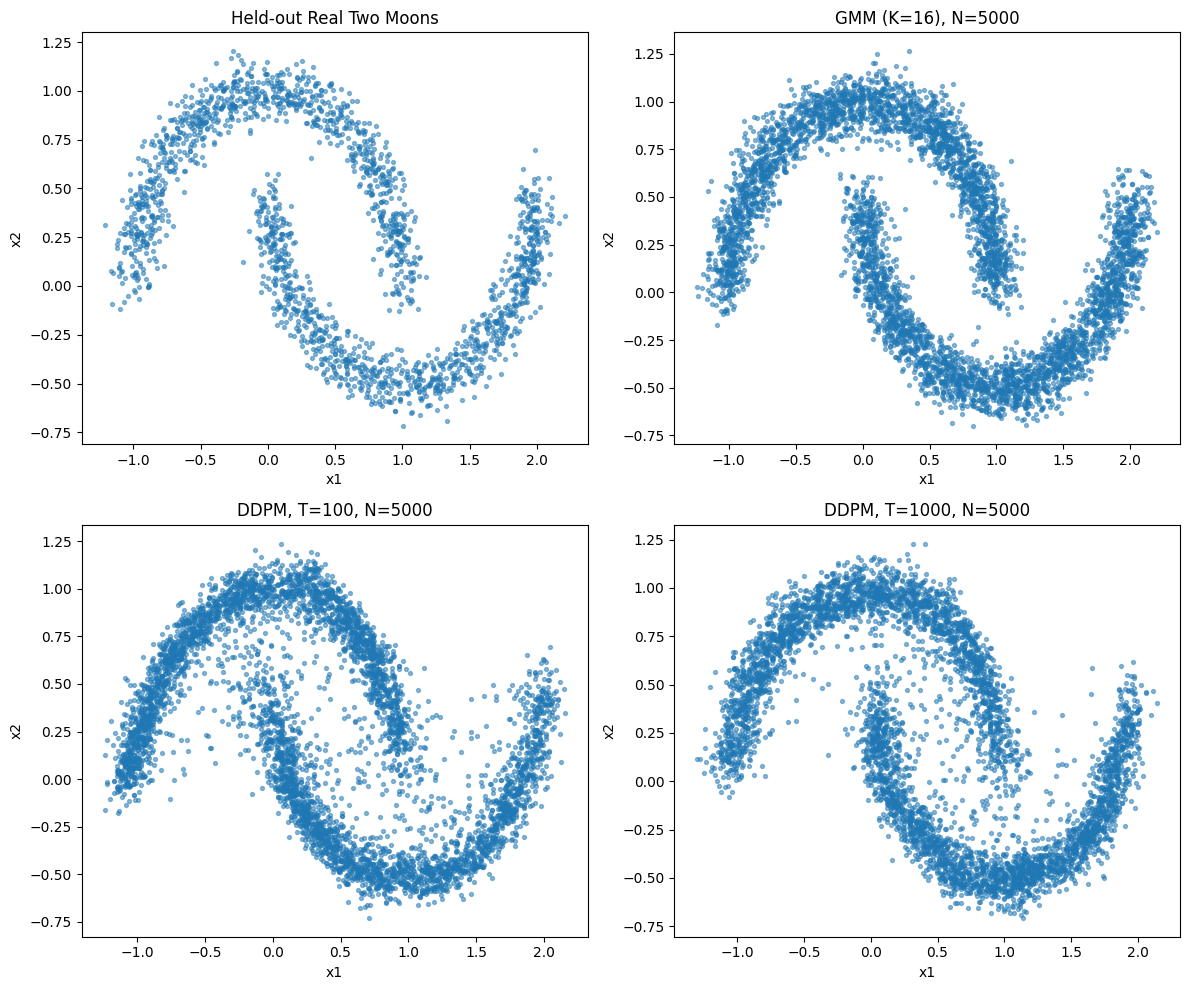

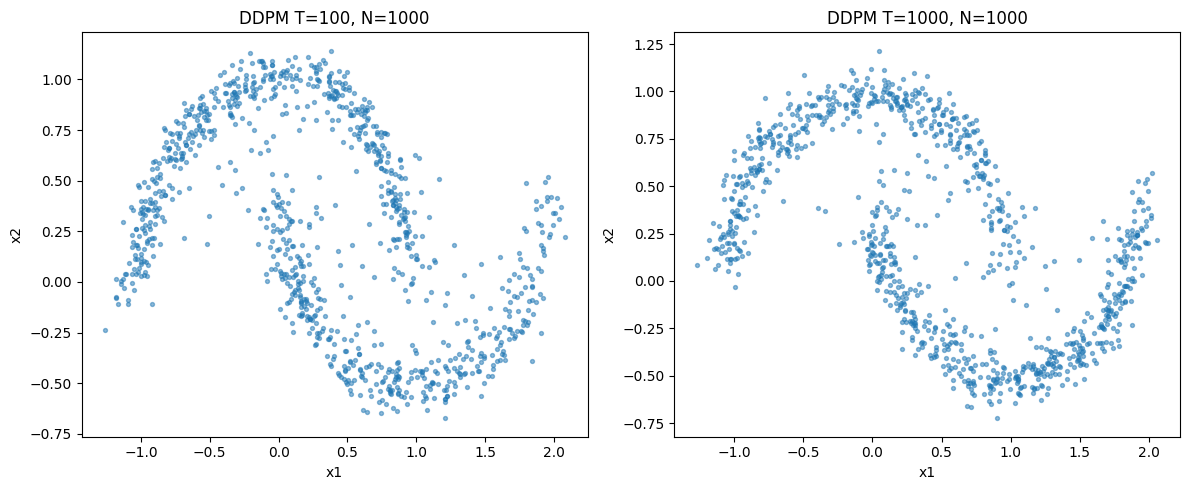

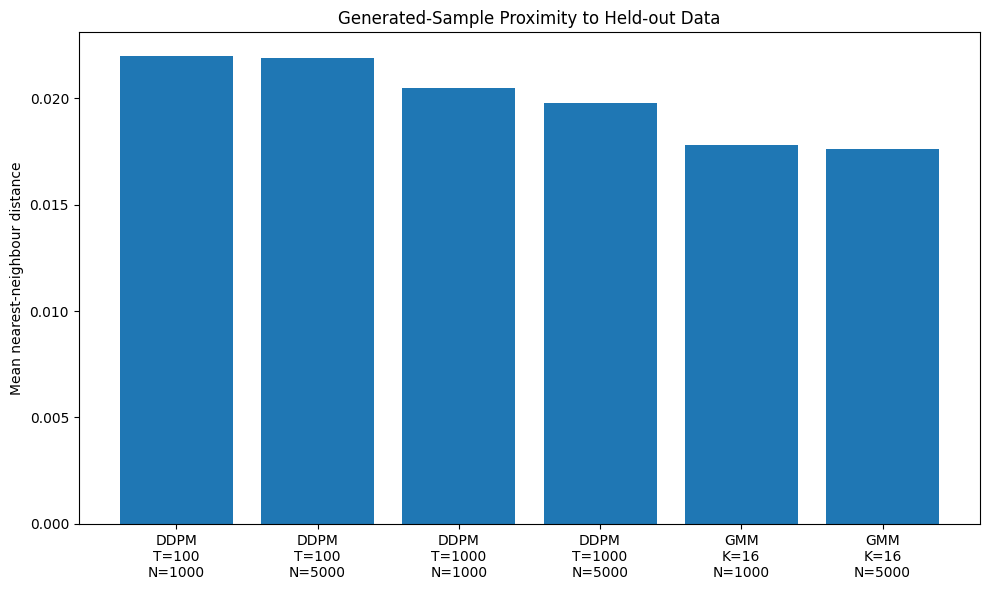

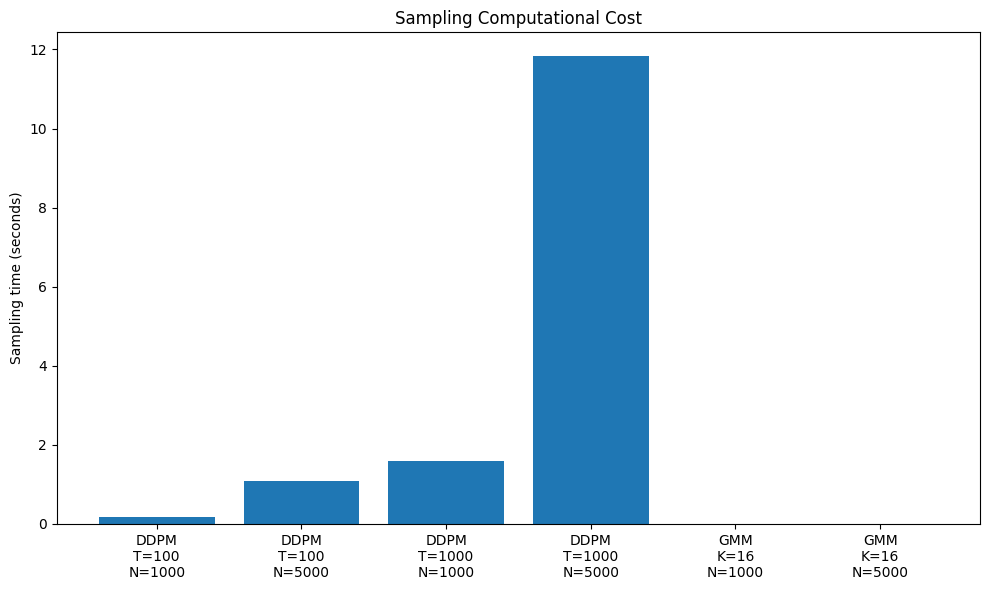


FINAL RESULTS TABLE


,Model,N,Mean_NN_Distance
0,DDPM T=100,1000,0.0220
1,DDPM T=100,5000,0.0219
2,DDPM T=1000,1000,0.0205
3,DDPM T=1000,5000,0.0198
4,GMM K=16,1000,0.0178
5,GMM K=16,5000,0.0176



Sampling-time table


,Model,N,Time
0,DDPM T=100,1000,0.177790
1,DDPM T=100,5000,1.084400
2,DDPM T=1000,1000,1.586150
3,DDPM T=1000,5000,11.841160
4,GMM K=16,1000,0.002159
5,GMM K=16,5000,0.002136



Saved:
Figure_1_Sample_Comparison.png
Figure_2_DDPM_Step_Comparison.png
Figure_3_NN_Distance.png
Figure_4_Sampling_Time.png


In [15]:
# ============================================================
# FINAL FIGURES FOR CSE756 REPORT
# DDPM vs GMM on Two Moons
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 70)
print("GENERATING FINAL REPORT FIGURES")
print("=" * 70)

# ------------------------------------------------------------
# Figure 1: Real data vs GMM vs DDPM
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Real held-out data
axes[0, 0].scatter(
    X_test[:, 0], X_test[:, 1],
    s=8, alpha=0.5
)
axes[0, 0].set_title("Held-out Real Two Moons")
axes[0, 0].set_xlabel("x1")
axes[0, 0].set_ylabel("x2")

# GMM
axes[0, 1].scatter(
    gmm_results["N5000"]["samples"][:, 0],
    gmm_results["N5000"]["samples"][:, 1],
    s=8, alpha=0.5
)
axes[0, 1].set_title("GMM (K=16), N=5000")
axes[0, 1].set_xlabel("x1")
axes[0, 1].set_ylabel("x2")

# DDPM T=100
axes[1, 0].scatter(
    ddpm_results["T100_N5000"]["samples"][:, 0],
    ddpm_results["T100_N5000"]["samples"][:, 1],
    s=8, alpha=0.5
)
axes[1, 0].set_title("DDPM, T=100, N=5000")
axes[1, 0].set_xlabel("x1")
axes[1, 0].set_ylabel("x2")

# DDPM T=1000
axes[1, 1].scatter(
    ddpm_results["T1000_N5000"]["samples"][:, 0],
    ddpm_results["T1000_N5000"]["samples"][:, 1],
    s=8, alpha=0.5
)
axes[1, 1].set_title("DDPM, T=1000, N=5000")
axes[1, 1].set_xlabel("x1")
axes[1, 1].set_ylabel("x2")

plt.tight_layout()
plt.savefig("Figure_1_Sample_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Figure 2: DDPM sampling-step comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Same N = 1000
axes[0].scatter(
    ddpm_results["T100_N1000"]["samples"][:, 0],
    ddpm_results["T100_N1000"]["samples"][:, 1],
    s=8, alpha=0.5
)
axes[0].set_title("DDPM T=100, N=1000")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

# T=1000
axes[1].scatter(
    ddpm_results["T1000_N1000"]["samples"][:, 0],
    ddpm_results["T1000_N1000"]["samples"][:, 1],
    s=8, alpha=0.5
)
axes[1].set_title("DDPM T=1000, N=1000")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")

plt.tight_layout()
plt.savefig("Figure_2_DDPM_Step_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Figure 3: Mean NN distance
# ------------------------------------------------------------

results_df = pd.DataFrame([
    ["DDPM T=100", 1000, 0.0220],
    ["DDPM T=100", 5000, 0.0219],
    ["DDPM T=1000", 1000, 0.0205],
    ["DDPM T=1000", 5000, 0.0198],
    ["GMM K=16", 1000, 0.0178],
    ["GMM K=16", 5000, 0.0176],
], columns=["Model", "N", "Mean_NN_Distance"])

fig, ax = plt.subplots(figsize=(10, 6))

labels = [
    "DDPM\nT=100\nN=1000",
    "DDPM\nT=100\nN=5000",
    "DDPM\nT=1000\nN=1000",
    "DDPM\nT=1000\nN=5000",
    "GMM\nK=16\nN=1000",
    "GMM\nK=16\nN=5000"
]

values = results_df["Mean_NN_Distance"].values

ax.bar(labels, values)
ax.set_ylabel("Mean nearest-neighbour distance")
ax.set_title("Generated-Sample Proximity to Held-out Data")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("Figure_3_NN_Distance.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Figure 4: Sampling time
# ------------------------------------------------------------

timing_df = pd.DataFrame([
    ["DDPM T=100", 1000, 0.17779],
    ["DDPM T=100", 5000, 1.08440],
    ["DDPM T=1000", 1000, 1.58615],
    ["DDPM T=1000", 5000, 11.84116],
    ["GMM K=16", 1000, 0.002159],
    ["GMM K=16", 5000, 0.002136],
], columns=["Model", "N", "Time"])

fig, ax = plt.subplots(figsize=(10, 6))

labels = [
    "DDPM\nT=100\nN=1000",
    "DDPM\nT=100\nN=5000",
    "DDPM\nT=1000\nN=1000",
    "DDPM\nT=1000\nN=5000",
    "GMM\nK=16\nN=1000",
    "GMM\nK=16\nN=5000"
]

ax.bar(labels, timing_df["Time"])
ax.set_ylabel("Sampling time (seconds)")
ax.set_title("Sampling Computational Cost")

plt.tight_layout()
plt.savefig("Figure_4_Sampling_Time.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Final table
# ------------------------------------------------------------

print("\nFINAL RESULTS TABLE")
display(results_df)

print("\nSampling-time table")
display(timing_df)

print("\nSaved:")
print("Figure_1_Sample_Comparison.png")
print("Figure_2_DDPM_Step_Comparison.png")
print("Figure_3_NN_Distance.png")
print("Figure_4_Sampling_Time.png")